In [12]:
##### Figures 3/4: exposed capital & labor globally (fig 3) and by country (fig 4)

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import rasterio.features
from matplotlib import gridspec

In [13]:
##### Load data

cd = Path.cwd().parent.parent

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"
capital_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"
labor_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif"

# production raster
production = f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif"

# priority raster
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"

# country boundaries
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [14]:
##### Shared helper / styling

def read_array(path, band=1):
    with rasterio.open(path) as src:
        arr = src.read(band).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
    return arr

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#6B7280",
}

STATUS_COLORS = {
    "Additional priority": "#D9D9D9",
    "Already in PA": "#595959",
}

TITLE_FS = 8   # subplot / panel titles
LABEL_FS = 7   # axis / legend labels, bar value annotations
TICK_FS = 6    # tick labels, country-name labels

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": TICK_FS,
    "axes.titlesize": TITLE_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LABEL_FS,
})

# Priority classification raster
priority_arr = read_array(biodiversity_with_PA)

# Observed/model values
value_rasters = {
    "Capital": capital,
    "Labor": labor,
    "Production": production,
}

In [15]:
##### Global summary table (needed for FIGURE 3 bar chart)

summary_rows = []

for variable, path in value_rasters.items():
    value_arr = read_array(path)
    global_total = np.nansum(value_arr)

    additional = np.nansum(value_arr[priority_arr == 1])
    already = np.nansum(value_arr[priority_arr == 2])
    total = additional + already

    summary_rows.append({
        "Variable": variable,
        "Additional_priority": additional,
        "Already_in_PA": already,
        "Total_priority": total,
        "Pct_additional": 100 * additional / global_total,
        "Pct_already": 100 * already / global_total,
        "Pct_total": 100 * total / global_total,
        "Global_total": global_total,
    })

summary_df = pd.DataFrame(summary_rows)

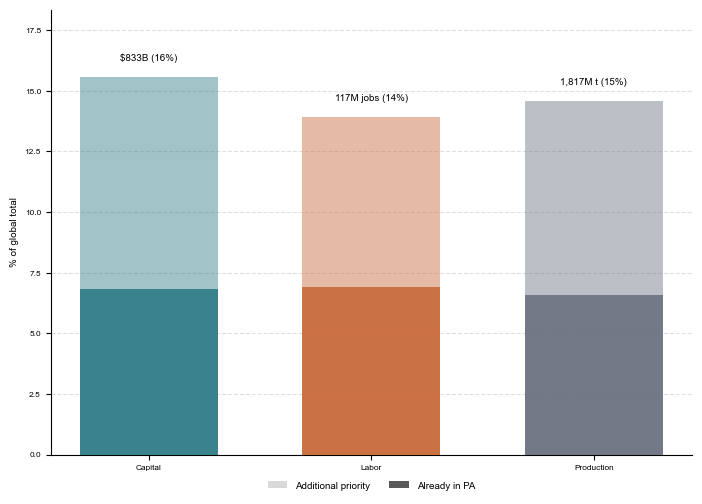

In [21]:
##### FIGURE 3: % of global capital, labor, production in priority regions

variables = ["Capital", "Labor", "Production"]
x = np.arange(len(variables))
width = 0.62

fig, ax = plt.subplots(figsize=(7, 5))

for i, variable in enumerate(variables):
    row = summary_df.loc[
        summary_df["Variable"] == variable
    ].iloc[0]

    # Darker shade = already PA; lighter shade = additional priority.
    # Use alpha to distinguish the two portions.
    ax.bar(
        i,
        row["Pct_already"],
        width,
        color=COLORS[variable],
        alpha=0.95,
        zorder=3,
    )

    ax.bar(
        i,
        row["Pct_additional"],
        width,
        bottom=row["Pct_already"],
        color=COLORS[variable],
        alpha=0.45,
        zorder=3,
    )

    # Absolute total + percentage label
    value = row["Total_priority"]

    if variable == "Capital":
        value_label = (
            f"${value / 1e9:,.0f}B"
            if value >= 1e9
            else f"${value / 1e6:,.0f}M"
        )
    elif variable == "Labor":
        value_label = (
            f"{value / 1e6:,.0f}M jobs"
            if value >= 1e6
            else f"{value / 1e3:,.0f}K jobs"
        )
    else:
        value_label = (
            f"{value / 1e6:,.0f}M t"
            if value >= 1e6
            else f"{value / 1e3:,.0f}K t"
        )

    ax.text(
        i,
        row["Pct_total"] + 0.6,
        f"{value_label} ({row['Pct_total']:.0f}%)",
        ha="center",
        va="bottom",
        fontsize=LABEL_FS,
    )

ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("% of global total")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(summary_df["Pct_total"]) * 1.18)

# Simplified five-item legend
legend_elements = [
    Patch(facecolor=STATUS_COLORS["Additional priority"], label="Additional priority"),
    Patch(facecolor=STATUS_COLORS["Already in PA"], label="Already in PA"),
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.savefig(
    f"{fd}/Figure_3_global_exposure.tiff",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [17]:
##### Prepare country-level data on capital, labor, and production in priority areas

# Merge country codes
country_shp = country_shp.merge(
    country_codes,
    left_on="GID_0",
    right_on="SHP_code",
    how="left",
)

# Use the capital raster as the reference grid
with rasterio.open(capital) as ref:
    ref_transform = ref.transform
    ref_shape = (ref.height, ref.width)
    ref_crs = ref.crs

country_shp_proj = (
    country_shp.to_crs(ref_crs)
    if country_shp.crs != ref_crs
    else country_shp.copy()
).reset_index(drop=True)

# Rasterize countries
shapes = (
    (geom, i)
    for i, geom in enumerate(country_shp_proj.geometry)
    if geom is not None
)

country_id_arr = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=ref_shape,
    transform=ref_transform,
    fill=-1,
    dtype="int32",
)

n_countries = len(country_shp_proj)
row_to_iso3 = country_shp_proj["ISO3"].to_dict()


def zonal_sum_by_country(
    value_arr,
    priority_arr,
    class_value,
    country_id_arr,
    n_countries,
):
    valid = (
        (country_id_arr >= 0)
        & (priority_arr == class_value)
        & ~np.isnan(value_arr)
    )

    return np.bincount(
        country_id_arr[valid],
        weights=value_arr[valid],
        minlength=n_countries,
    )


# Country-average rasters
country_avg_rasters = {
    "Capital": capital_country_avg,
    "Labor": labor_country_avg,
    # No production country-average raster currently provided
}


# National totals for each variable
national_totals = {}

for variable, path in value_rasters.items():
    arr = read_array(path)
    valid = (country_id_arr >= 0) & ~np.isnan(arr)

    totals = np.bincount(
        country_id_arr[valid],
        weights=arr[valid],
        minlength=n_countries,
    )

    national_totals[variable] = {
        row_to_iso3[i]: totals[i]
        for i in range(n_countries)
    }


# Country-level priority totals
country_rows = []

for variable, path in value_rasters.items():
    arr = read_array(path)

    for class_value, class_name in [
        (1, "Additional priority"),
        (2, "Already in PA"),
    ]:
        sums = zonal_sum_by_country(
            arr,
            priority_arr,
            class_value,
            country_id_arr,
            n_countries,
        )

        for i in range(n_countries):
            iso3 = row_to_iso3[i]
            national_total = national_totals[variable].get(
                iso3,
                np.nan,
            )

            country_rows.append({
                "ISO3": iso3,
                "Variable": variable,
                "Class": class_name,
                "Sum": sums[i],
                "National_Total": national_total,
            })

country_df = pd.DataFrame(country_rows)


# Priority-area-only global totals
global_priority_totals = {
    variable: np.nansum(
        read_array(path)[(priority_arr == 1) | (priority_arr == 2)]
    )
    for variable, path in value_rasters.items()
}

country_df["Pct_of_national"] = np.where(
    country_df["National_Total"] > 0,
    100 * country_df["Sum"] / country_df["National_Total"],
    np.nan,
)

country_df["Global_Total"] = country_df["Variable"].map(global_priority_totals)

country_df["Pct_of_global"] = (
    100 * country_df["Sum"] / country_df["Global_Total"]
)


# Total priority value by country
country_totals = (
    country_df
    .groupby(["ISO3", "Variable"], as_index=False)
    .agg(
        Priority_Total=("Sum", "sum"),
        National_Total=("National_Total", "first"),
        Pct_of_national=("Pct_of_national", "sum"),
        Pct_of_global=("Pct_of_global", "sum"),
    )
)

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_47520/1192792587.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


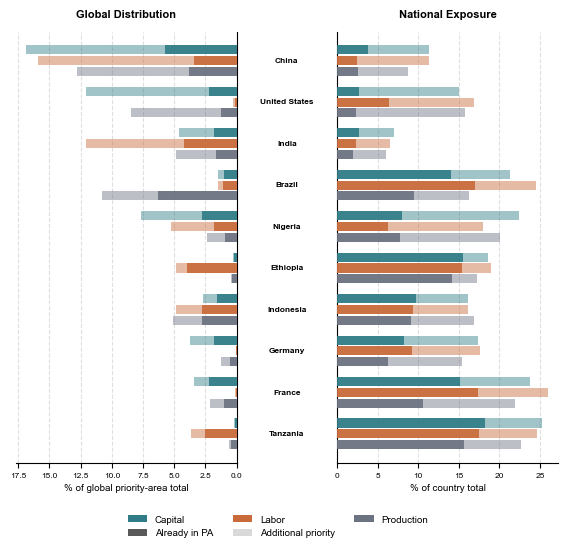

In [22]:
##### FIGURE 4: country exposure butterfly chart

def plot_country_butterfly(
    country_df,
    country_totals,
    country_shp_proj,
    top_n=10,
):

    # Rank separately by each variable and interleave rankings
    rankings = {}

    for variable in ["Capital", "Labor", "Production"]:
        rankings[variable] = (
            country_totals[
                (country_totals["Variable"] == variable)
                & (country_totals["ISO3"] != "OTHER")
            ]
            .sort_values(
                "Pct_of_global",
                ascending=False,
            )["ISO3"]
            .tolist()
        )

    country_list = []
    rank = 0

    while (
        len(country_list) < top_n
        and rank < max(len(v) for v in rankings.values())
    ):
        for variable in ["Capital", "Labor", "Production"]:
            ranked = rankings[variable]

            if (
                rank < len(ranked)
                and ranked[rank] not in country_list
            ):
                country_list.append(ranked[rank])

            if len(country_list) == top_n:
                break

        rank += 1

    name_col = next(
        (
            c
            for c in [
                "COUNTRY",
                "NAME_0",
                "Country",
                "country_name",
            ]
            if c in country_shp_proj.columns
        ),
        None,
    )

    if name_col:
        name_lookup = (
            country_shp_proj[
                ["ISO3", name_col]
            ]
            .drop_duplicates("ISO3")
            .set_index("ISO3")[name_col]
        )
    else:
        name_lookup = pd.Series(dtype=object)

    def get_values(iso3, variable, pct_col):
        sub = country_df[
            (country_df["ISO3"] == iso3)
            & (country_df["Variable"] == variable)
        ]

        already = sub.loc[
            sub["Class"] == "Already in PA",
            pct_col,
        ].sum()

        additional = sub.loc[
            sub["Class"] == "Additional priority",
            pct_col,
        ].sum()

        return already, additional

    n = len(country_list)
    bar_h = 0.22
    offset = bar_h + 0.04

    fig = plt.figure(
        figsize=(7, 0.4 * n + 1.6)
    )

    gs = gridspec.GridSpec(
        1,
        3,
        width_ratios=[4, 1.5, 4],
        wspace=0.05,
    )

    ax_left = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharey=ax_left)
    ax_right = fig.add_subplot(gs[2], sharey=ax_left)

    y_positions = np.arange(n)[::-1]

    for y, iso3 in zip(
        y_positions,
        country_list,
    ):

        for variable, y_off in [
            ("Capital", offset),
            ("Labor", 0),
            ("Production", -offset),
        ]:

            already_g, additional_g = get_values(
                iso3,
                variable,
                "Pct_of_global",
            )

            already_n, additional_n = get_values(
                iso3,
                variable,
                "Pct_of_national",
            )

            # Global distribution
            ax_left.barh(
                y + y_off,
                already_g,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_left.barh(
                y + y_off,
                additional_g,
                bar_h,
                left=already_g,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

            # National exposure
            ax_right.barh(
                y + y_off,
                already_n,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_right.barh(
                y + y_off,
                additional_n,
                bar_h,
                left=already_n,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

    # Axes
    ax_left.set_xlabel(
        "% of global priority-area total",
        fontsize=LABEL_FS,
    )

    ax_left.invert_xaxis()

    ax_left.spines[
        ["top", "left"]
    ].set_visible(False)

    ax_left.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_left.set_axisbelow(True)
    ax_left.set_title(
        "Global Distribution",
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=10,
    )

    ax_left.yaxis.set_visible(False)

    ax_right.set_xlabel(
        "% of country total",
        fontsize=LABEL_FS,
    )

    ax_right.spines[
        ["top", "right"]
    ].set_visible(False)

    ax_right.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_right.set_axisbelow(True)

    ax_right.set_title(
        "National Exposure",
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=10,
    )

    ax_right.yaxis.set_visible(False)

    ax_mid.axis("off")

    for y, iso3 in zip(
        y_positions,
        country_list,
    ):
        ax_mid.text(
            0.5,
            y,
            name_lookup.get(iso3, iso3),
            ha="center",
            va="center",
            fontsize=TICK_FS,
            fontweight="bold",
        )

    ax_mid.set_xlim(0, 1)
    ax_left.set_ylim(-0.7, n - 0.3)

    # Legend
    # col1: Capital/Already in PA, col2: Labor/Additional priority, col3: Production
    legend_elements = [
        Patch(
            facecolor=COLORS["Capital"],
            label="Capital",
        ),
        Patch(
            facecolor=STATUS_COLORS["Already in PA"],
            label="Already in PA",
        ),
        Patch(
            facecolor=COLORS["Labor"],
            label="Labor",
        ),
        Patch(
            facecolor=STATUS_COLORS["Additional priority"],
            label="Additional priority",
        ),
        Patch(
            facecolor=COLORS["Production"],
            label="Production",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        fontsize=LABEL_FS,
    )


    plt.tight_layout(
        rect=[0, 0, 1, 0.93]
    )

    plt.savefig(
        f"{fd}/Figure_4_country_exposure.tiff",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

plot_country_butterfly(
    country_df,
    country_totals,
    country_shp_proj,
)